In [8]:
import time
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input

In [9]:
path = "/content/drive/MyDrive/Aprendizado - Notebooks Colab/ResNet50V2 Transfer Learning/archive"
train_path = path + "/train"
val_path = path + "/val"
test_path = path + "/test"

# ResNet50V2 Transfer Learning on a Chest X-Ray Pneumonia Classification

# Equipe:
*   Carlos Henrique Miranda Esteves;
*   Lucas Almeida Miralha de Figueiredo;
*   Lucas Andrey Nunes de Aragão.

# Overview:

O projeto "ResNet50V2 Transfer Learning on a Chest X-Ray Pneumonia Classification" é baseado na pesquisa [Identifying Medical Diagnoses and Treatable Diseases by Image-Based Deep Learning](https://www.cell.com/cell/fulltext/S0092-8674(18)30154-5), no qual os pesquisadores utilizaram o método de transfer learning na classificação de degeneração macular relacionada à idade e edema macular diabético através de imagens tomografia de coerência óptica (OCT). Os pesquisadores também demonstraram a eficiência do modelo na classificação pediátrica de pneumonia com base em imagens de raio-x do toráx.

Os dados utilizados neste trabalho foram extraídos do repositório Kaggle: [Chest X‑Ray Pneumonia — Balanced Dataset](https://www.kaggle.com/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/data). As imagens deste repositório são as mesmas imagens utilizadas no estudo acima. Para o nosso experimento, configuramos o modelo CNN ResNet50V2 para classificação de imagens através do procedimento de transfer learning via Keras Tensorflow. Outros modelos CNN também podem ser utilizados para a tarefa de classificação de imagens.

Este notebook colab é responsável por: processar os dados, configurar e adaptar o modelo ResNet50V2 via transfer learning, treinamento do modelo, plotagem e análise de dados e exploração do GridSearch

# Direitos Autorais

As imagens utilizadas neste notebook colab são de autoria de Aurélien Geron, autor do livro Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow. Imagens, explicações teóricas do funcionamento do uso de CNN's e código fonte são de autoria de Aurélien Geron. Link para aquisição do livro: [Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow](https://www.amazon.com.br/Mãos-Obra-Aprendizado-Scikit-Learn-Inteligentes/dp/8550826456/ref=sr_1_2?crid=12PQ0NFG10U49&dib=eyJ2IjoiMSJ9.N97X5WDhjZrNKhN1w0I4znhJnfHqAy9_UsfvUtPRPplPQNhm-3qRg6J_DPD4UF7ua3frSmbDIzTZzenfqLo25KoWZqmUZnWcIPLx3xvdASTsdpk7YjbdOoUIt22sF_jJ2oz5qGsIQp-0EhgUJVkg6dIXVh_pTwtkr7Dp3Hz4QKqYLmuLaKtXe88Nyrabddle.HOR18zUrW2LwoouaHiVCQ_lihQ5iDr4lKWHz63BD_Y4&dib_tag=se&keywords=mãos+a+obra+aprendizado+de+maquina&qid=1774744923&sprefix=%2Caps%2C212&sr=8-2)

# Uso de IA Generativa

Durante a confecção deste experimento, a IA generativa Gemini 3 - Raciocínio foi utilizada nos seguintes aspectos:


*   Fundamentação Teórica e Conceitual (aprendizado teórico);
*   Adaptação do Código do Autor Para o Modelo Utilizado Neste Experimento;
*   Decisões Relacionado ao Uso de GPU;
*   Edições, Formulações e Contribuições de Código;
*   Auxílio na Tomada de Decisões Relacionadas a Partes Críticas de Configuração da CNN;
*   Escrita Parcial de Texto.





# 1°: Processamento de Dados

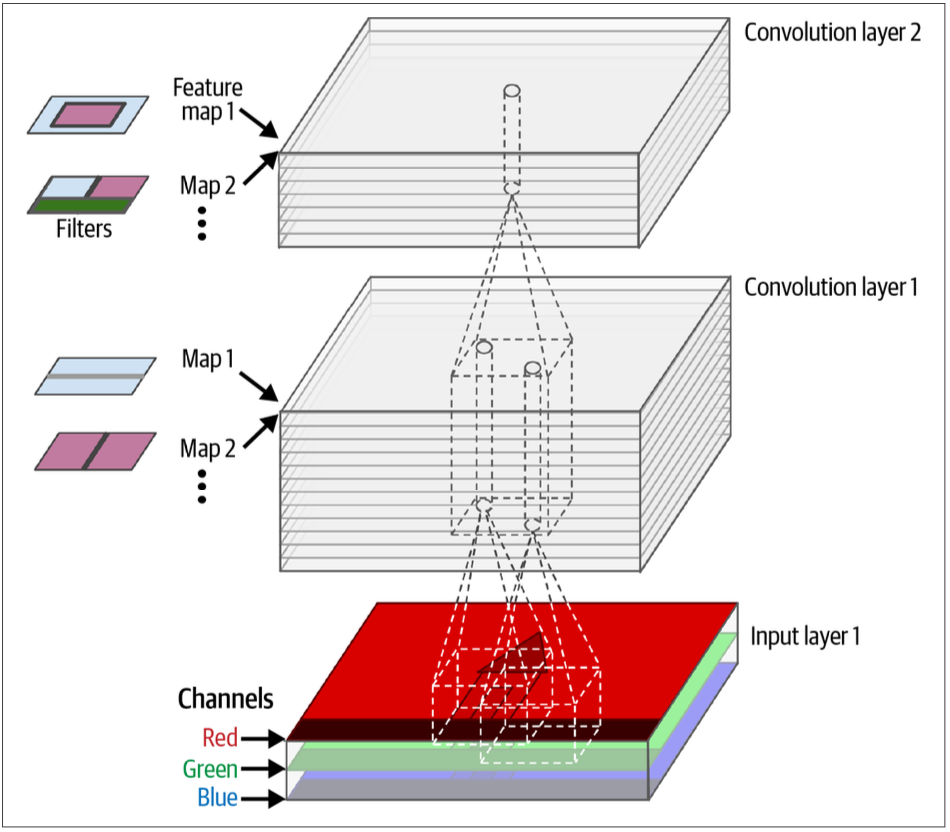
A primeira etapa antes de executar o ResNet50V2 consiste em tratar os dados. No nosso caso, os dados que serão introduzidos no modelo são imagens de raios-x do tórax. O modelo ResNet50V2 tem entradas de 224 por 224. Por padrão, o ResNet50V2 Transfer Learning tem arquitetura que aceita entradas RGB (canal 3 de entrada), nosso dataset tem somente 1 canal de tons de cinza. O modelo ResNet50V2 possui 25.5 milhões de parâmetros.

Na primeira etapa, estamos preocupados em realizar as seguintes tarefas:


1.   Padronizar o tamanho dos dados para os inputs do ResNet50V2;
2.   Padronizar o tamanho do canal dos dados para para os inputs do ResNet50V2;
3.   Dividir o dataset em: treino, validação e teste;
4.   Realizar o processo de augmentação de dados.



In [10]:
# Tamanho do Batch de Dados
BATCH_SIZE = 64

# Padronização do tamanho das imagens para o input do ResNet50V2
IMG_SIZE = (224, 224)

# Mesmo sendo um canal (tons de cinza), o ResNet50V2 de transfer learning
# espera trabalhar com RGB
IMG_SHAPE = IMG_SIZE + (3,)

# Carga do dataset de treinamento (necessário embaralhamento dos dados)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    label_mode='binary',
    color_mode='rgb',
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE)

# Carga do dataset de treinamento
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    label_mode='binary',
    color_mode='rgb',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE)

# Carga do dataset de treinamento (caso necessário)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    label_mode='binary',
    color_mode='rgb',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE)

Found 6800 files belonging to 2 classes.
Found 6800 files belonging to 2 classes.
Found 30 files belonging to 2 classes.


# 2°: Personalização do Modelo Transfer Learning ResNet50V2

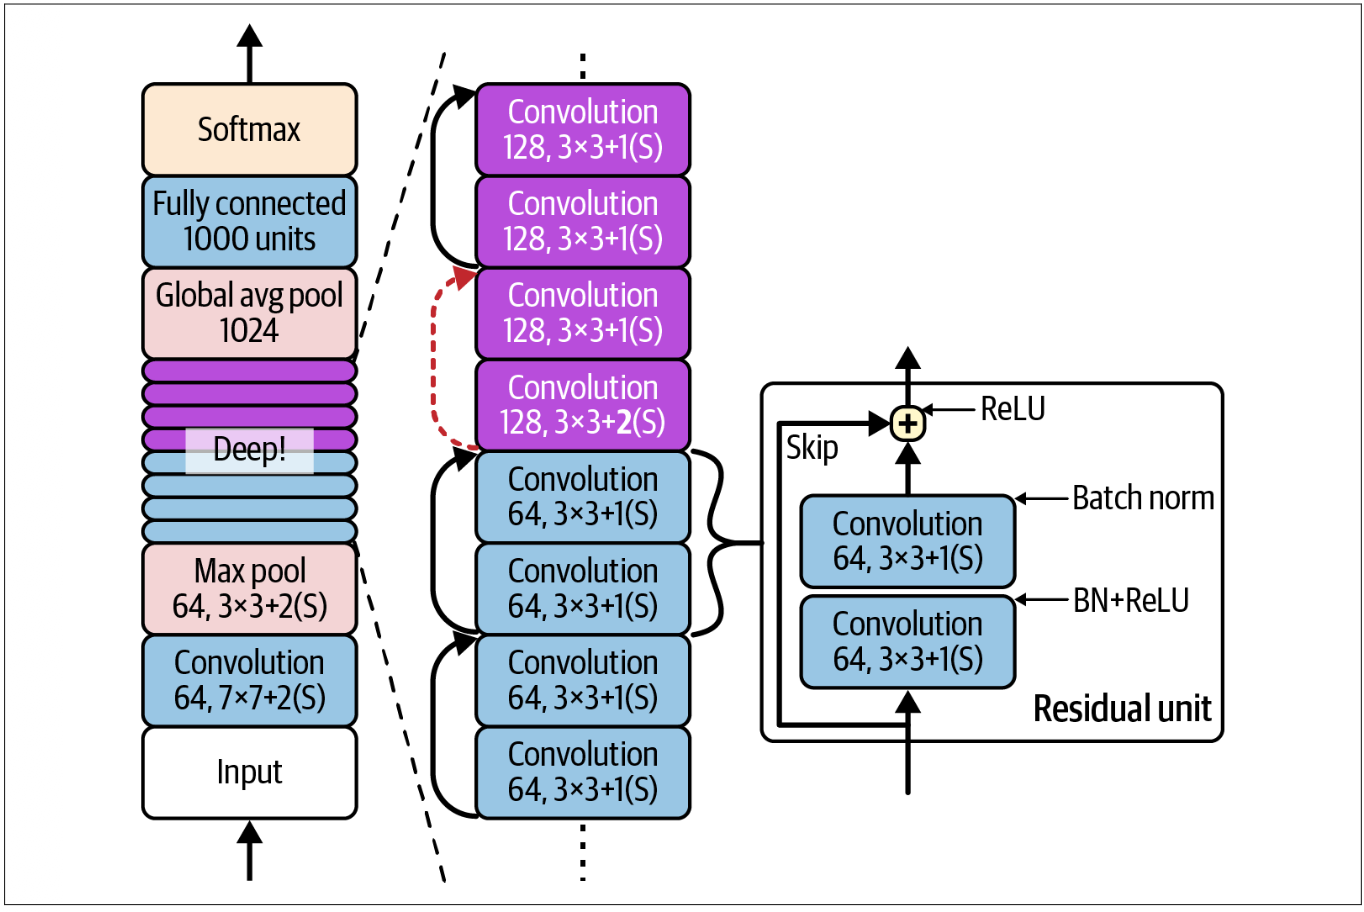

Nesta seção, não implementaremos o modelo ResNet50 do 0. Ao invés disso, vamos recorrer a técnica do transfer learning: vamos utilizar uma CNN pronta capaz de reconhecer imagens (em torno de 1000 classes) com parâmetros prontos e vamos reconfigurar o modelo para o nosso problema: classificar as imagens em somente duas classes: com pneumonia e sem pneumonia.

Para tornar isso possível, precisamos fazer umas modificações, a primeira delas é o topo do modelo. Como é possível ver na imagem de cima, o topo apresenta três unidades importantes: saida softmax, camada densa conectada com 1000 unidades e um global avarage pool de 1024 pontos. Nosso objetivo é gerar somente duas saídas, portanto, precisamos remover a classificação de 1000 unidades

# 3°: Treinamento

Por fim, a ultima etapa é a etapa de treinamento. Aqui temos algumas configurações importantes: otimizador, parâmetros do otimizador, metricas que desejamos analisar etc. As principais métricas que precisamos utilizar são: accuracy, precisão, recall e auc. Abaixo, definimos alguns dos possíveis resultados do nosso treinamento e classificação:

*   **Verdadeiro Positivo (TP):** O modelo classificou como "Doente" e a pessoa está doente.
*   **Verdadeiro Negativo (TN):** O modelo classificou como "Saudável" e a pessoa está saudável.
*   **Falso Positivo (FP):** O modelo classificou como "Doente", mas a pessoa está saudável (Alarme Falso).
*   **Falso Negativo (FN):** O modelo classificou como "Saudável", mas a pessoa está doente (Erro Perigoso).

Todos esse possíveis resultados que podemos obter da nossa classificação, permite criar algumas métricas de avaliação do desempenho do modelo:



1.   **Accuracy (Acurácia):** de tudo o que o modelo previu, quanto ele acertou no total (tanto positivos quanto negativos).
$$\text{Acurácia} = \frac{TP + TN}{\text{Total de casos}}$$

2.   **Precision (Precisão):** De todos os que o modelo classificou como positivos, quantos eram realmente positivos?
$$\text{Precisão} = \frac{TP}{TP + FP}$$

3.   **Recall:** De todos os que são realmente positivos na vida real, quantos o modelo conseguiu encontrar? Devemos considerar essa métrica para verificar os falsos positivos e evitar submeter uma pessoa a um tratamento desnecessário
$$\text{Recall} = \frac{TP}{TP + FN}$$

4.   **Area Under the Curve (Área Sobre a Curva):** mede a capacidade de separação do modelo. Ou seja, o quão bem o seu modelo consegue distinguir entre a classe 0 e a classe 1.

In [11]:
# Definindo as épocas a serem testadas
epoch_tests = [10, 25, 50, 75, 100]

# Dicionários para armazenar o histórico e o modelo final de cada teste
histories = {}
models = {}

for epochs in epoch_tests:
    print(f'Iniciando treino de {epochs} épocas com base congelada...')

    # 1. Limpando a sessão ANTES de construir o modelo para garantir memória limpa
    tf.keras.backend.clear_session()

    # 2. RECRIANDO TUDO DO ZERO DENTRO DO LOOP

    data_augmentation = tf.keras.Sequential([
                    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
                    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
                    tf.keras.layers.RandomZoom(0.1, seed=42)
    ])

    base_model = ResNet50V2(weights='imagenet',
                            include_top=False,
                            input_shape=IMG_SHAPE)
    base_model.trainable = False # Congelando a base novamente

    # for layer in base_model.layers:
    #   layer.trainable = False

    inputs = tf.keras.Input(shape=IMG_SHAPE)
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    # 3. Compilando o modelo recém-criado
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=[
                  'accuracy',
                  tf.keras.metrics.Precision(name='precision'),
                  tf.keras.metrics.Recall(name='recall'),
                  tf.keras.metrics.AUC(name='auc')
              ])

    # 5. Treinamento
    history = model.fit(
        train_dataset,
        epochs=epochs,
        validation_data=validation_dataset,
    )

    # 6. Salvando os resultados e o modelo treinado
    histories[epochs] = history
    models[epochs] = model

    print("\n")

Iniciando treino de 10 épocas com base congelada...
Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 52s 430ms/step - accuracy: 0.9024 - auc: 0.9642 - loss: 0.2416 - precision: 0.9062 - recall: 0.8976 - val_accuracy: 0.9496 - val_auc: 0.9909 - val_loss: 0.1283 - val_precision: 0.9625 - val_recall: 0.9356
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 239ms/step - accuracy: 0.9521 - auc: 0.9895 - loss: 0.1288 - precision: 0.9580 - recall: 0.9456 - val_accuracy: 0.9541 - val_auc: 0.9941 - val_loss: 0.1167 - val_precision: 0.9834 - val_recall: 0.9238
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 239ms/step - accuracy: 0.9549 - auc: 0.9905 - loss: 0.1209 - precision: 0.9599 - recall: 0.9494 - val_accuracy: 0.9684 - val_auc: 0.9956 - val_loss: 0.0909 - val_precision: 0.9813 - val_recall: 0.9550
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 239ms/step - accuracy: 0.9582 - auc: 0.9922 - loss: 0.1103 - precision: 0.9609 - recall: 0.9553 - val_accuracy: 0.9216 - val_auc: 0.9943 - val_loss: 0.1926 - val_precisi

# 4°: Plotagem dos resultados

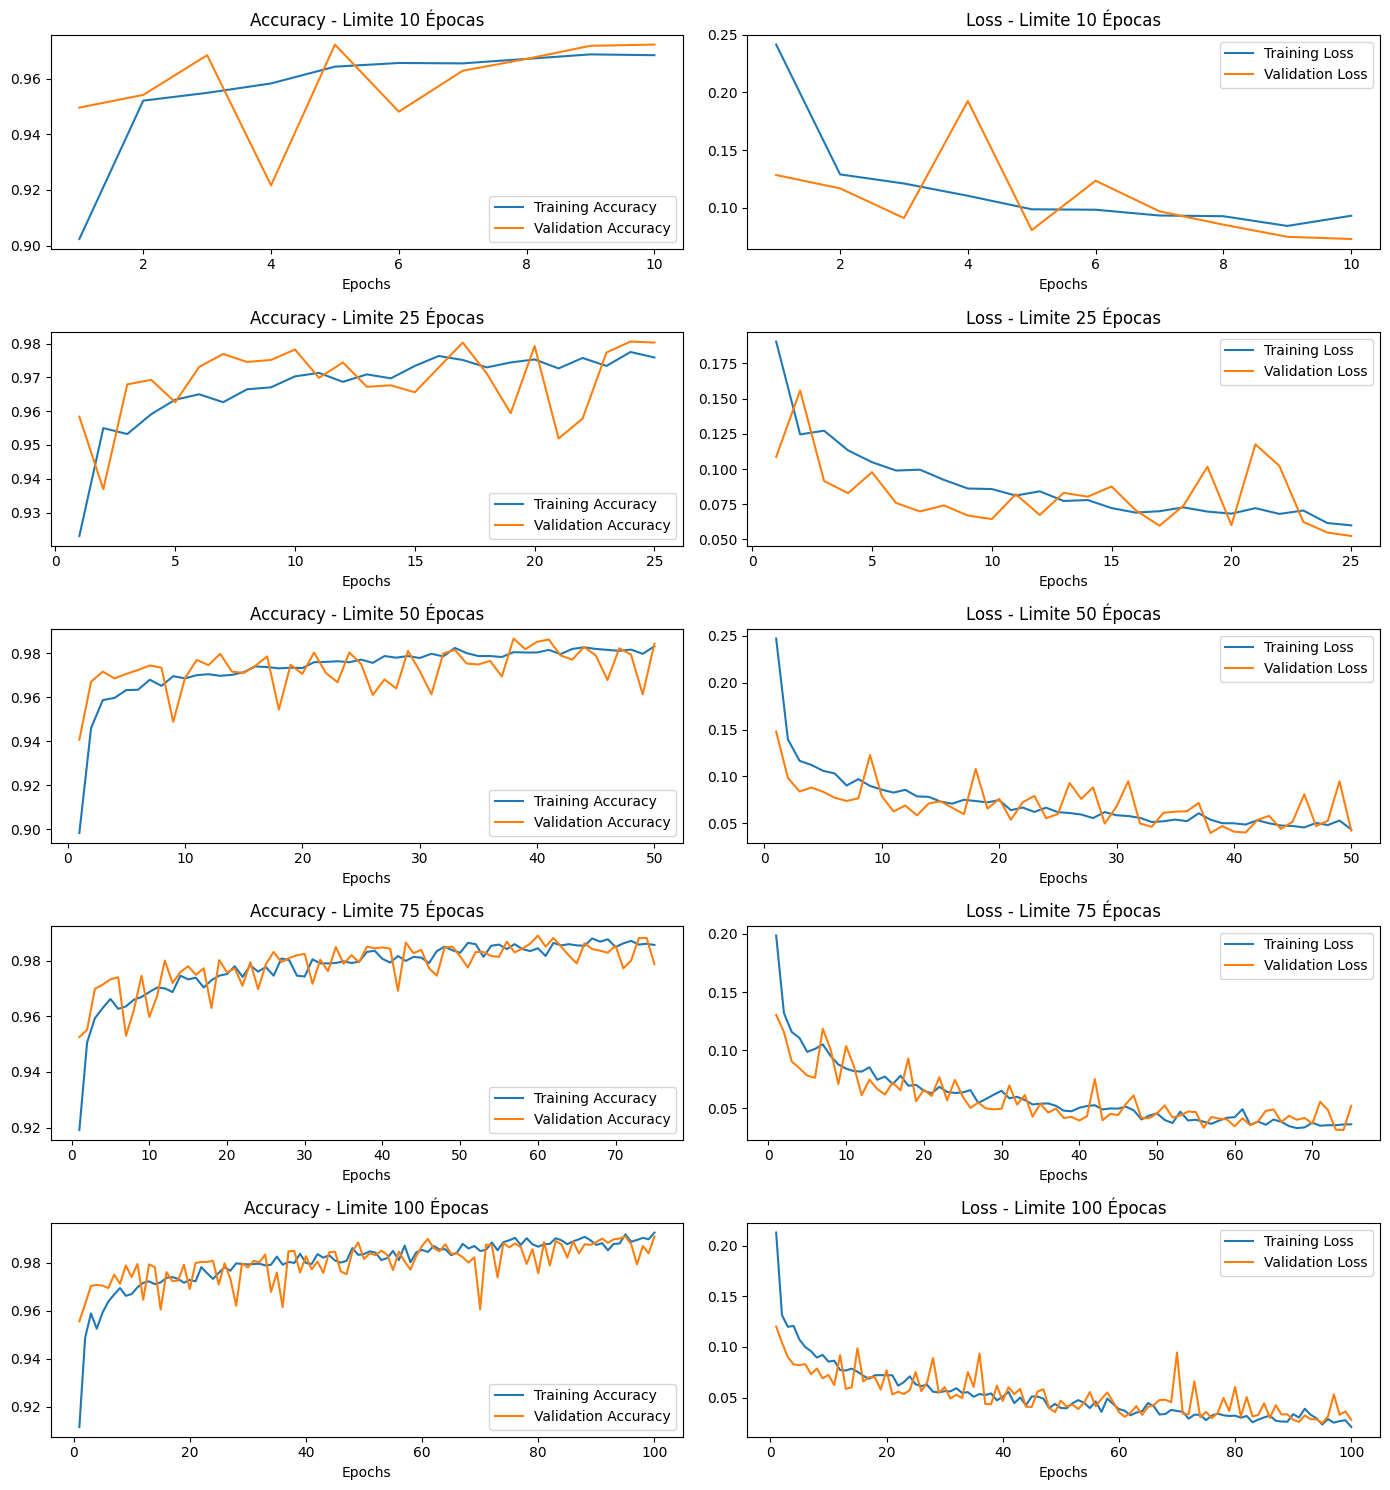

In [18]:
plt.figure(figsize=(14, 15)) # Ajustando o tamanho para acomodar 6 gráficos

for i, epochs in enumerate(epoch_tests):
    # Extraindo dados do histórico de cada modelo
    acc = histories[epochs].history['accuracy']
    val_acc = histories[epochs].history['val_accuracy']
    loss = histories[epochs].history['loss']
    val_loss = histories[epochs].history['val_loss']

    # Criando um eixo X dinâmico com base em quantas épocas realmente rodaram
    eixo_x = range(1, len(acc) + 1)

    # Gráfico de Acurácia
    plt.subplot(5, 2, 2*i + 1)
    plt.plot(eixo_x, acc, label='Training Accuracy')
    plt.plot(eixo_x, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'Accuracy - Limite {epochs} Épocas')
    plt.xlabel('Epochs')

    # Gráfico de Perdas (Loss)
    plt.subplot(5, 2, 2*i + 2)
    plt.plot(eixo_x, loss, label='Training Loss')
    plt.plot(eixo_x, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'Loss - Limite {epochs} Épocas')
    plt.xlabel('Epochs')

plt.tight_layout()
plt.show()


RESULTADOS DO MODELO - TREINADO COM LIMITE DE 10 ÉPOCAS


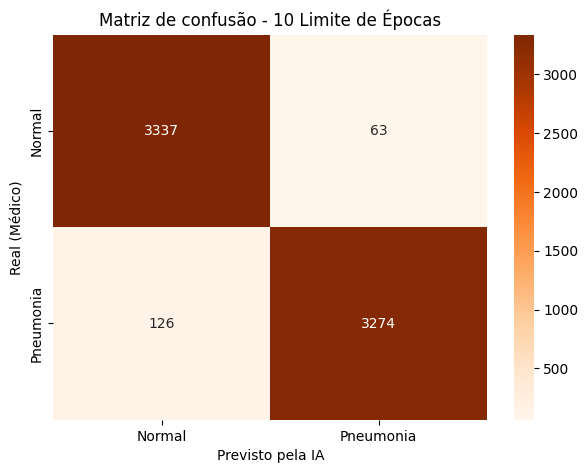


Relatório de Classificação (Limite de 10 Épocas):
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97      3400
   Pneumonia       0.98      0.96      0.97      3400

    accuracy                           0.97      6800
   macro avg       0.97      0.97      0.97      6800
weighted avg       0.97      0.97      0.97      6800




RESULTADOS DO MODELO - TREINADO COM LIMITE DE 25 ÉPOCAS


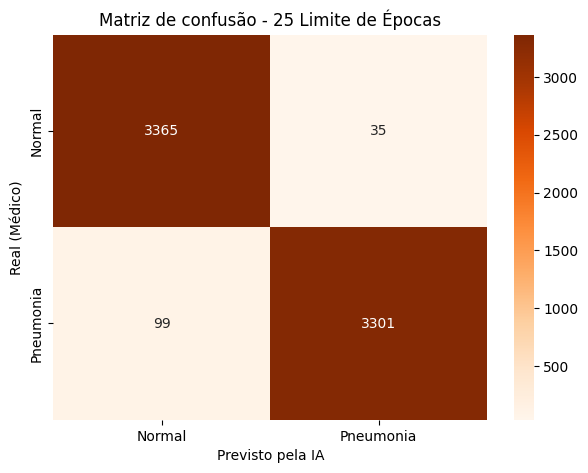


Relatório de Classificação (Limite de 25 Épocas):
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98      3400
   Pneumonia       0.99      0.97      0.98      3400

    accuracy                           0.98      6800
   macro avg       0.98      0.98      0.98      6800
weighted avg       0.98      0.98      0.98      6800




RESULTADOS DO MODELO - TREINADO COM LIMITE DE 50 ÉPOCAS


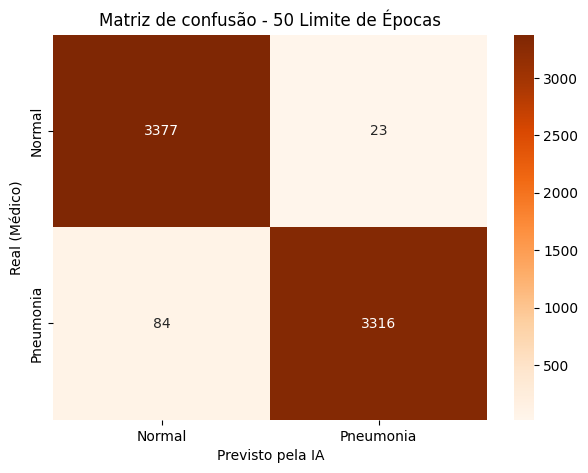


Relatório de Classificação (Limite de 50 Épocas):
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98      3400
   Pneumonia       0.99      0.98      0.98      3400

    accuracy                           0.98      6800
   macro avg       0.98      0.98      0.98      6800
weighted avg       0.98      0.98      0.98      6800




RESULTADOS DO MODELO - TREINADO COM LIMITE DE 75 ÉPOCAS


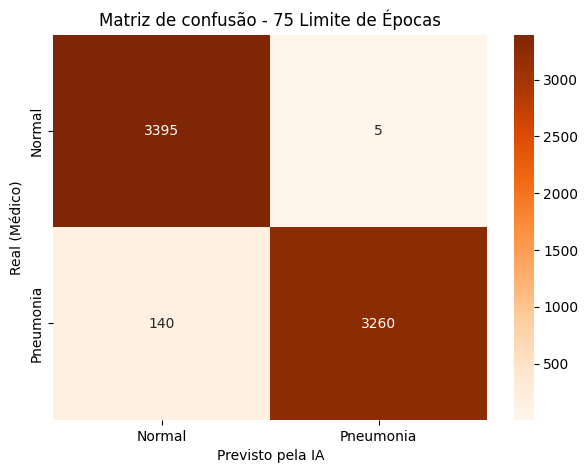


Relatório de Classificação (Limite de 75 Épocas):
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98      3400
   Pneumonia       1.00      0.96      0.98      3400

    accuracy                           0.98      6800
   macro avg       0.98      0.98      0.98      6800
weighted avg       0.98      0.98      0.98      6800




RESULTADOS DO MODELO - TREINADO COM LIMITE DE 100 ÉPOCAS


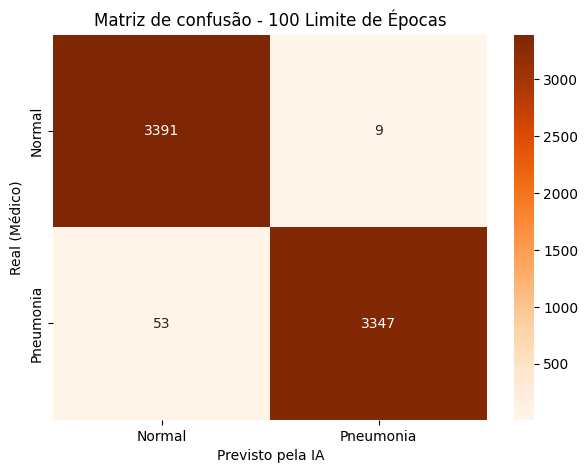


Relatório de Classificação (Limite de 100 Épocas):
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      3400
   Pneumonia       1.00      0.98      0.99      3400

    accuracy                           0.99      6800
   macro avg       0.99      0.99      0.99      6800
weighted avg       0.99      0.99      0.99      6800





In [15]:
for epochs in epoch_tests:
    print(f'\n{"="*60}')
    print(f'RESULTADOS DO MODELO - TREINADO COM LIMITE DE {epochs} ÉPOCAS')
    print(f'{"="*60}')

    y_true = []
    y_pred = []

    # Pegando as imagens e os labels do dataset de validação
    for images, labels in validation_dataset:
        # Usando o modelo específico salvo nesta chave do dicionário
        preds = models[epochs].predict(images, verbose=0)
        y_true.extend(labels.numpy())
        # Como a saída da Sigmoid é probabilidade (0 a 1), usamos o limiar de 0.5
        y_pred.extend((preds > 0.5).astype(int))

    # Aqui geramos a matriz
    cm = confusion_matrix(y_true, y_pred)

    # Plotando o gráfico
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Normal', 'Pneumonia'],
                yticklabels=['Normal', 'Pneumonia'])
    plt.xlabel('Previsto pela IA')
    plt.ylabel('Real (Médico)')
    plt.title(f'Matriz de confusão - {epochs} Limite de Épocas')
    plt.show()

    # Relatório completo (Precision, Recall, F1)
    print(f"\nRelatório de Classificação (Limite de {epochs} Épocas):")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))
    print("\n")

# 5°: Análise específica de Hiperparâmetro

É possível verificar que não houve diferença significativa no desempenho do modelo ao mudar seu número de épocas, com sua precisão sendo quase inalterada. Com mais iterações do teste geral, pode ser possível que haja uma melhora futura, da mesma forma que uma melhora pode ser perceptível caso o limite de Early Stopping seja ajustado de acordo com o número de épocas escolhidos, no presente caso, utilizou-se baixa tolerância/paciência.

In [16]:
import pandas as pd

print("Resumo dos resultados da Análise de Épocas:\n")
results_list = []

for epochs in epoch_tests:
    # Coletando a melhor acurácia de validação do histórico
    max_val_acc = max(histories[epochs].history['val_accuracy'])

    # Encontrando o índice (época) em que ocorreu essa melhor acurácia
    best_epoch_index = histories[epochs].history['val_accuracy'].index(max_val_acc)

    # Pegando as outras métricas nessa mesma época de melhor desempenho
    best_val_loss = histories[epochs].history['val_loss'][best_epoch_index]
    best_val_recall = histories[epochs].history['val_recall'][best_epoch_index]

    # Checando quantas épocas realmente rodaram antes do Early Stopping agir
    actual_epochs_trained = len(histories[epochs].history['val_accuracy'])

    results_list.append({
        'Max Épocas Permitidas': epochs,
        'Épocas Reais Treinadas': actual_epochs_trained,
        'Época do Melhor Resultado': best_epoch_index + 1,
        'Val Accuracy': round(max_val_acc, 4),
        'Val Loss': round(best_val_loss, 4),
        'Val Recall': round(best_val_recall, 4)
    })

# Exibindo os resultados num formato de tabela bem limpo
df_epoch_analysis = pd.DataFrame(results_list)
display(df_epoch_analysis)

Resumo dos resultados da Análise de Épocas:



,Max Épocas Permitidas,Épocas Reais Treinadas,Época do Melhor Resultado,Val Accuracy,Val Loss,Val Recall
0,10,10,5,0.9722,0.0804,0.9747
1,25,25,24,0.9806,0.0549,0.9826
2,50,50,38,0.9866,0.0397,0.9918
3,75,75,60,0.9890,0.0343,0.9882
4,100,100,95,0.9909,0.0250,0.9909
